<a href="https://colab.research.google.com/github/DavidSenseman/STA1403/blob/main/Chapter_05A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- STA1403_CHAPTER_05A:Rev 1 -->

---------------------------
**COPYRIGHT NOTICE:** This Jupyterlab Notebook is a Derivative work of [Jeff Heaton](https://github.com/jeffheaton) licensed under the Apache License, Version 2.0 (the "License"); You may not use this file except in compliance with the License. You may obtain a copy of the License at

> [http://www.apache.org/licenses/LICENSE-2.0](http://www.apache.org/licenses/LICENSE-2.0)

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

------------------------

# **STA 1403: Biostatistics**

## **Chapter 5: Random Variables and Probability Distributions**

* Instructor: [David Senseman](mailto:David.Senseman@utsa.edu), [Department of Biology, Health and the Environment](https://sciences.utsa.edu/bhe/), [UT San Antonio](https://www.utsa.edu/)

#### Contents
* **5.1 : Random Variable**
* **5.2 : Discrete vs. Continuous**
* **5.3 : Probability Distributions**
* **5.4 : Discrete Probability Distributions**
* 5.5 : Continuous Probability Distributions
* 5.6 : Cumulative Distribution Function and Quantiles
* 5.7 : Scaling and Shifting Random Variables
* 5.8 : Sum of Two Random Variables
* 5.9 : Advanced

## Google Colab Instructions

Run next code cell to map this Colab lesson's folder /content/drive to your Google Drive. This will allow you keep a copy of this Colab notebook which **_is_** your course textbook.

In [ ]:
# @title **Run this cell first**
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    Colab = True
    print("Note: Using Google CoLab")
    !curl ipinfo.io
except:
    print("**WARNING**: Your GDrive is not mapped to /content/drive ")
    print("**WARNING**: Your work will not be saved!")
    Colab = False

Mounted at /content/drive
Note: Using Google CoLab
{
  "ip": "34.132.154.175",
  "hostname": "175.154.132.34.bc.googleusercontent.com",
  "city": "Council Bluffs",
  "region": "Iowa",
  "country": "US",
  "loc": "41.2619,-95.8608",
  "org": "AS396982 Google LLC",
  "postal": "51502",
  "timezone": "America/Chicago",
  "readme": "https://ipinfo.io/missingauth"
}

You should see something _similar_ to the following output:
```text
Mounted at /content/drive
Note: Using Google CoLab
{
  "ip": "34.139.115.187",
  "hostname": "187.115.139.34.bc.googleusercontent.com",
  "city": "North Charleston",
  "region": "South Carolina",
  "country": "US",
  "loc": "32.8546,-79.9748",
  "org": "AS396982 Google LLC",
  "postal": "29415",
  "timezone": "America/New_York",
  "readme": "https://ipinfo.io/missingauth"
}
```

## Test Your STA1403 Key

Run the next cell to test whether your STA1403 Key is correctly installed in your Colab Secrets. If asked, grant access to your Colab Secrets.

In [ ]:
# @title Test Your STA1403 KEY

from google.colab import userdata
import os

# Check if  key is properly loaded
try:
    # 1. Get the key from Secrets
    STA1403_KEY = userdata.get('STA1403_KEY')

    # 2. Set it as an environment variable
    os.environ['STA1403_KEY'] = STA1403_KEY

    print("STA1403 key loaded and environment variable set successfully!")
    print(f"Key length: {len(STA1403_KEY)}")

except Exception as e:
    print(f"Error loading STA1403 key: {e}")
    print("Please set your STA1403 key in Google Colab:")
    print("1. Go to Secrets in the left sidebar (key icon)")
    print("2. Create a new secret named 'STA1403_KEY'")
    print("3. Paste your STA1403 key and toggle 'Notebook access' on")

STA1403 key loaded and environment variable set successfully!
Key length: 26


If your STA1403 Key is correctly stored in your Colab Secrets, you should see the following output:
```text
STA1403 key loaded and environment variable set successfully!
Key length: 28
```

If your STA1403 Key is not correct, you need to contact your course instructor. You will **not** be able to submit this Colab notebook for a grade until you resolve this issue.

# **Chapter 5 : Random Variables and Probability Distributions**

## **5.1 Random Variables**

In the previous chapter, we discussed random events and their probabilities. We used the possible genotypes of a bi-allelic gene **A** as an example. We defined its sample space, $S = \{AA, Aa, aa\}$, and various events, such as the homozygous event $HM = \{AA, aa\}$. We then discussed such concepts as the complement, union, intersection, conditional probability, and independence.

The focus of this chapter is random variables and their probability distributions. Formally, a **random variable** $X$ assigns a numerical value to each possible outcome (and event) of a random phenomenon. For instance, we can define $X$ based on possible genotypes of a bi-allelic gene **A** as follows:

$$
X = \left\{\begin{array}{ll} 0 &\text{for genotype AA},\\1 &\text{for genotype Aa}, \\ 2 & \text{for genotype aa}. \end{array}\right.
$$

In this case, the random variable assigns $0$ to the outcome $AA$, $1$ to the outcome $Aa$, and $2$ to the outcome $aa$. The way we specify random variables based on a specific random phenomenon is not unique. For the above example, we can define another random variable $Y$ as follows:

$$
Y = \left\{\begin{array}{ll}0 & \text{for genotypes AA and aa}, \\ 1 & \text{for genotype Aa}.\end{array} \right.
$$

In this case, $Y$ assigns $0$ to the homozygous event and assigns $1$ to the heterozygous event. When the underlying outcomes are numerical, the values the random variable assigns to each outcome can be the same as the outcome itself. For the die rolling example, we can define a random variable $Z$ to be equal to $1, 2, ..., 6$ for outcomes $1, 2, ..., 6$, respectively. Alternatively, we can define a random variable $W$ and set $W$ to $1$ when the outcome is an odd number and to $2$ when the outcome is an even number.

The set of values that a random variable can assume is called its **range**. For the above examples, the range of $X$ and $Z$ is $\{0,1,2\}$, and the range of $Z$ is $\{1, 2, \ldots, 6\}$.

After we define a random variable, we can find the probabilities for its possible values based on the probabilities for its underlying random phenomenon. This way, instead of talking about the probabilities for different outcomes and events, we can talk about the probability of different values for a random variable. Assume that the probabilities for different genotypes are $P(AA)=0.49$, $(Aa)=0.42$, and $P(aa) = 0.09$. Then, instead of saying $P(AA)=0.49$, i.e., the genotype is $AA$ with probability $0.49$, we can say that $P(X = 0)=0.49$, i.e., $X$ is equal to $0$ with probability of $0.49$. Likewise, $P(X = 1) = 0.42$ and $P(X = 2) = 0.09$. Note that the total probability for the random variable is still $1$. For the die rolling example, instead of saying that the probability of observing an odd number is $1/2$ when rolling a die, we can say $P(W = 1) = 1/2$, i.e., $W$ is equal to $1$ with probability of $1/2$.

In what follows, we write $P(X)$ to denote the probability of a random variable $X$ in general without specifying any value or range of values. Since the probability of a random variable is defined based on the probability of its underlying random phenomenon, the probability rules we discussed in the previous chapter also apply to random variables. Specifically, concepts such as independence and conditional probability are defined similarly for random variables as they are defined for random events. For example, when two random variables do not affect each other's probabilities, we say that they are independent.

As mentioned above, this chapter focuses on random variables and their probability distributions.

---------------------

>The probability distribution of a random variable specifies its possible values (i.e., its range) and their corresponding probabilities.

--------------------

For the random variable X defined based on genotypes, the probability distribution can be simply specified as follows:

$$
P(X = x) = \left\{\begin{array}{ll} 0.49 & \text {for }x = 0, \\ 0. 4 2 & \text {for } x = 1, \\ 0. 0 9 & \text {for } x = 2.\end{array}\right.
$$

Here, $x$ denotes a specific value (i.e., 0,1, or 2) of the random variable.

Probability distributions are specified differently for different types of random variables. In the following section, we divide the random variables into two major groups: **discrete** and **continuous**. Then, we provide several examples for each group.


## **5.2 Discrete vs. Continuous**

The grouping of random variables into discrete and continuous is based on their range. Discrete random variables can take a countable set of values. These variables can be categorical (nominal or ordinal), such as genotype, gender, disease status, or pain level. They can also be counts, such as the number of patients visiting an emergency room per day, or the number of lymph nodes containing evidence of cancer. For all these examples, we can count the number of possible values the random variable can take. In the above genotype examples, $X$ is a discrete random variable since it can take 3 possible values only.

Continuous random variables can take an uncountable number of possible values. Examples include weight, body temperature, BMI, and blood pressure. Consider the random variable $Y$ for birthweight, which is a random phenomenon. In this case, the values of the random variables (i.e., numbers it assigns to each possible outcome) are the same as the corresponding outcomes; $Y = 7.9$ if the birthweight is $7.9$ pounds. In this example, we cannot count the possible values of $Y$. For any two possible values of this random variable, we can always find another value between them. Consider $7.9$ pounds and $8.0$ pounds as two possible values for $Y$. We can find another number such as $7.95$ between these two values. Now consider $7.9$ and $7.95$ as possible values; we can still find another number between them, such as $7.93$. For continuous random variables, we can continue this process for any two possible values no matter how close they are. This is not the case for discrete random variables. While you can find another possible value between $70$ heart beats per minute and $75$ heart beats per minute, you cannot do so for $70$ and $71$; there is no other possible value between them.

## **5.3 Probability Distributions**

The probability distribution of a random variable provides the required information to find the probability of its possible values. Recall that the total probability of all possible values is equal to 1. Therefore, probability distribution specifies how the total probability of 1 is allocated among all possible values.

While the focus of earlier chapters was on exploring observed data and their distribution, here, we are concerned about all the possible values a random variable can take and their corresponding probabilities (i.e., the chance of observing those values) as opposed to a sample of observations. Although we do not necessarily need to think about a population when talking about probability distributions, it is easier to discuss this concept with a population in mind. Therefore, throughout this book, we usually discuss random variables and their probability distributions in the context of a population. That is, a random variable represents a specific random characteristic of a population and the possible values for that characteristic, even though we might not see many of those values in our sample. The probability distribution of a random variable specifies its range of possible values and how often we expect to see those values in the population. In that sense, our discussion of random variables and their distributions in this chapter remains at population level and theoretical (since we almost never have access to the whole population).

The probability distributions discussed here are characterized by one or two **parameters**. (In general, probability distributions can depend on more than two parameters.) These are values that define the form of a probability distribution. The parameters of probability distributions we assume for random variables are usually unknown. Typically, we use Greek alphabets such as $\mu$ and $\sigma$ to denote these parameters and distinguish them from known values.

While the probability distribution of a random variable is treated as the theoretical distribution of that random variable in the population, our study of probability distributions involves some analogous concepts as those discussed in earlier chapters regarding the distribution of observed data. More specifically, we are interested in specifying the mean and variance (or standard deviation) of a random variable as its measures of location and dispersion, respectively. Note, however, that the mean and variance here refer to the **population mean** and **population variance**, as opposed to sample mean and sample variance; hence, they remain theoretical, which means that we never know their true values. The mean of a random variable is also called its _expected_ value even. (Note that the mean of a random variable is not its typical value in general.) We usually use $\mu$ to denote the mean of a random variable and use $\sigma^{2}$ to denote its variance; the standard deviation of a random variable is therefore $\sigma$. For a population of size $N$, the mean and variance are calculated as follows:

$$
\mu = \frac{\sum_{i = 1}^{N}x _ {i}}{N},
$$

$$
\sigma^{2} = \frac{\sum_ {i = 1}^{N}\left(x_{i}-\mu\right)^{2}}{N},
$$

where $x_{i}$ is the value of the random variable for the $i$th member of the population.

In the remaining parts of this chapter, we discuss probability distributions for discrete and continuous random variables separately. We also discuss some commonly used discrete and continuous probability distributions. For each probability distribution, we provide the mean and variance and interpret them as the population mean and population variance for the corresponding random variable. Further, we use Python to plot probability distributions.


## **5.4 Discrete Probability Distributions**

For discrete random variables, the probability distribution is fully defined by the **probability mass function (pmf)**. This is a function that specifies the probability of each possible value within range of random variable. For the genotype example, the pmf of the random variable $X$ is

$$
P (X = x) = \left\{ \begin{array}{l l} 0.49 & \text {for } x = 0, \\ 0.42 & \text {for } x = 1, \\ 0.09 & \text {for } x = 2. \end{array} \right.
$$

The probabilities for all possible values of the random variable sum to one.

As another example, suppose $Y$ is a random variable that is equal to $1$ when a newborn baby has low birthweight, and is equal to $0$ otherwise. We say $Y$ is a _binary_ random variable. Further, assume that the probability of having a low birthweight for babies is $0.3$. Then the pmf for the random variable $Y$ is

$$
P (Y = y) = \left\{ \begin{array}{ll} 0.7 & \text {for } y = 0,\\0.3 & \text{for } y = 1.\end{array}\right.
$$

Note that in this case, the random variable can take two values only. Since $P(Y=1)=0.3$ and the total probability of all possible values is $1$, then we know that $P(Y=0)=0.7$.

In the following sections, we introduce some of the most commonly used probability mass functions for distributions of discrete random variables. For each distribution, we will provide the mean and variance as measures of location and spread, respectively. Moreover, with Python we will visualize these distributions, obtain probabilities, and simulate data (i.e., artificially generate a set of observed values).


### **_5.4.1 Bernoulli Distribution_**

Binary random variables are abundant in scientific studies. Examples include disease status (healthy and diseased), gender (male and female), survival status (dead, survived), and a gene with two possible alleles (A and a). We usually regard one of the values as the outcome of interest and denote it as $X = 1$. The other outcome is denoted as $X = 0$. As before, the probabilities for all possible values sum to one: $P(X = 0) + P(X = 1) = 1$.

-----------------

>The binary random variable $X$ with possible values $0$ and $1$ has a **Bernoulli** distribution with parameter $\theta$, where $P(X=1)=\theta$ and $P(X=0)=1-\theta$. We denote this as $X\sim\text{Bernoulli}(\theta)$, where $0\leq\theta\leq1$.

---------------

Here, $\theta$ is the unknown parameter. If $\theta$ were known, we could fully specify the probability mass function:

$$
P (X = x) = \left\{\begin{array}{ll} 1-\theta & \text{for } x = 0, \\ \theta & \text {for } x = 1. \end{array}\right.
$$

Sometimes we use the notation $ P(X|\theta) $ to emphasize the dependence of the probabilities on the value of $\theta$ (i.e., given $\theta$). Here, we simply show these probabilities as $P(X=0)$ and $P(X=1)$, where the dependence on $\theta$ is implied.

For example, let $X$ be a random variable representing the five-year survival status of breast cancer patient, where $X = 1$ if the patient survived and $X = 0$ otherwise. Suppose that the probability of survival is $\theta = 0.8$ : $P(X = 1) = 0.8$. Therefore, the probability of not surviving is $P(X = 0) = 1-\theta = 0.2$. Then $X$ has a Bernoulli distribution with parameter $ \theta = 0.8 $ , and we denote this as

$$
X \sim\operatorname{Bernoulli} (0. 8).
$$

The pmf for this distribution is

$$
P (X = x) = \left\{\begin{array}{ll} 0. 2 & \text {for } x = 0, \\ 0. 8 & \text {for } x = 1.\end{array} \right.
$$

## Example 1: Plot Bernoulli pmf

The code in the cell below shows the Python code to plot the probability mass function (pmf) for a $\operatorname{Bernoulli} (0.5)$ distribution. Some of you might wonder why a **binomial pmf function** was used in this code snippet if we are plotting a **_Bernoulli_** pmf:
```Python
# Bernoulli outcomes and their probabilities
x_values = np.arange(0, num_trials + 1)
probabilities = binom.pmf(x_values, num_trials, prob)
```
The answer is that the pmf of a Bernoulli trial is _exactly_ the same as a Bionomial pmf for a single trial (`num_trials=1`).


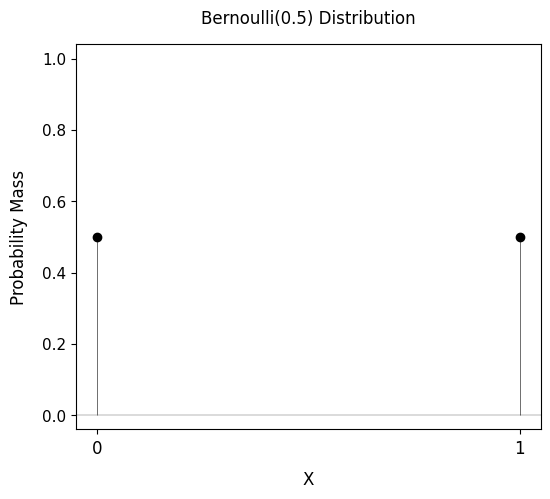

In [ ]:
# @title Example 1: Plot Bernoulli pmf

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials=1       # Number of trials
prob = 0.5         # Probability of success
# ──────────────────────────────────────────────────────────────────────────────


# Bernoulli outcomes and their probabilities
x_values = np.arange(0, num_trials + 1)
probabilities = binom.pmf(x_values, num_trials, prob)

# Create the figure
fig, ax = plt.subplots(figsize=(6, 5))

# Stem plot (vertical lines from x-axis to each point)
markerline, stemlines, baseline = ax.stem(
    x_values, probabilities,
    linefmt='k-',       # black vertical lines
    markerfmt='ko',     # black circular markers
    basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Add baseline
ax.axhline(y=0, color='k', linewidth=0.2)

# X-axis: only 0 and 1
ax.set_xticks(x_values)
ax.set_xticklabels(['0', '1'], fontsize=12)

# Y-axis: 0.0 to 1.0 in steps of 0.2
ax.set_ylim(-0.04, 1.04)
ax.set_yticks(np.arange(0.0, 1.1, 0.2))
ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0.0, 1.1, 0.2)], fontsize=11)

# Labels and title
ax.set_xlabel('X', fontsize=12, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=12, labelpad=10)
ax.set_title('Bernoulli(0.5) Distribution', fontsize=12, pad=15)

# Show plot
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image05A.png)

Note that the probability of each of the two outcomes is the same. This would be the probability of tossing a fair coin, with 50% heads ($0$) and 50% tails ($1$).

## **Exercise 1: Plot Bernoulli pmf**

In the cell below, write the Python code to plot the probability mass function (pmf) for a $\operatorname{Bernoulli}(0.8)$ distribution. Make sure you change the title.

**Code Hints:**

1. Copy-and-paste Example 1 into the cell below
2. Change the variables in the Input Section to read as shown in the following code chunk:
```Python
# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials=1       # Number of trials
prob = 0.8         # Probability of success
# ──────────────────────────────────────────────────────────────────────────────
```


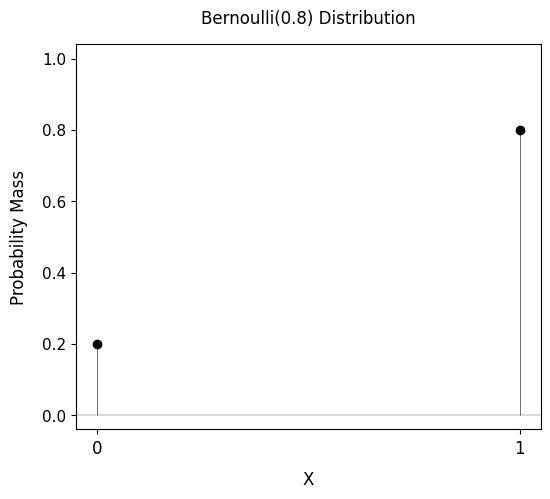

In [ ]:
# @title Exercise 1: Plot Bernoulli pmf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials=1       # Number of trials
prob = 0.8         # Probability of success
# ──────────────────────────────────────────────────────────────────────────────

# Bernoulli outcomes and their probabilities
x_values = np.arange(0, num_trials + 1)
probabilities = binom.pmf(x_values, num_trials, prob)

# Create the figure
fig, ax = plt.subplots(figsize=(6, 5))

# Stem plot (vertical lines from x-axis to each point)
markerline, stemlines, baseline = ax.stem(
    x_values, probabilities,
    linefmt='k-',       # black vertical lines
    markerfmt='ko',     # black circular markers
    basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Add baseline
ax.axhline(y=0, color='k', linewidth=0.2)

# X-axis: only 0 and 1
ax.set_xticks(x_values)
ax.set_xticklabels(['0', '1'], fontsize=12)

# Y-axis: 0.0 to 1.0 in steps of 0.2
ax.set_ylim(-0.04, 1.04)
ax.set_yticks(np.arange(0.0, 1.1, 0.2))
ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0.0, 1.1, 0.2)], fontsize=11)

# Labels and title
ax.set_xlabel('X', fontsize=12, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=12, labelpad=10)
ax.set_title('Bernoulli(0.8) Distribution', fontsize=12, pad=15)

# Show plot
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image06A.png)

Alternatively, we can plot pmf for visualizing the distribution. The output from **Exercise 1** (above), shows the plot of pmf for the $\operatorname{Bernoulli} (0.8)$ distribution. The height of each bar is the probability of the corresponding value on the horizontal axis. The height of the bar is $0.2$ at $X = 0$ and $0.8$ at $X = 1$. Since the probabilities for all possible values of the random variable add to $1$, the bar heights also add up to $1$.

-------------------

>The mean of a binary random variable, $X$, with Bernoulli($\theta$) distribution is $\theta$. We show this as $\mu = \theta$. In this case, the mean can be interpreted as the proportion of the population who have the outcome of interest. Furthermore, the variance of a random variable with Bernoulli($\theta$) distribution is $\sigma^{2} = \theta(1-\theta) = \mu(1-\mu)$. The standard deviation is obtained by taking the square root of variance: $\sigma = \sqrt{\theta(1-\theta)} = \sqrt{\mu(1-\mu)}$.

-----------------

In the above example, $\mu = 0.8$. Therefore, we expect $80%$ of patients survive. The variance of the random variable is $\sigma^{2} = 0.8 \times 0.2 = 0.16$, and its standard deviation is $\sigma = 0.4$. This reflects the extent of variability in survival status from one person to another. For this example, the amount of variation is rather small. Therefore, we expect to see many survivals $(X = 1)$ with occasional death $(X = 0)$. For comparison, suppose that the probability of survival for bladder cancer is $\theta = 0.6$. Then, the variance becomes $\sigma^{2} = 0.6 \times (1 - 0.6) = 0.24$. This reflects a higher variability in the survival status for bladder cancer patients compared to that of breast cancer patients.


### **_5.4.2 Binomial Distribution_**

A sequence of binary random variables $X_{1}, X_{2},\ldots,X_{n}$ is called **Bernoulli trials** if they all have the same Bernoulli distribution (i.e., the same probability $\theta$ for the outcome of interest) and are independent (i.e., not affecting each other's probabilities). For example, suppose that we plan to recruit a group of $50$ patients with breast cancer and study their survival within five years from diagnosis. We represent the survival status for these patients by a set of Bernoulli random variables $X_{1},\ldots, X_{50}$. (For each patient, the outcome is either $0$ or $1$.) Assuming that all patients have the same survival probability, $\theta = 0.8$, and the survival status of one patient does not affect the probability of survival for another patient, $X_{1},\ldots, X_{50}$ form a set of $50$ Bernoulli trials.

Now we can create a new random variable Y representing the number of patients out of 50 who survive for five years. The number of survivals is the number of 1s in the set of Bernoulli trials. This is the same as the sum of Bernoulli trials, whose values are either $0$ or $1$:

$$
Y = \sum_ {i}^{n} X_{i},
$$

where $X_{i}=1$ if the $i$th patient survives and $X_{i}=0$ otherwise.

Since $Y$ can be any integer number from $0$ (no one survives) through $50$ (everyone survives), its range is $\{0, 1,\ldots, 50\}$. The range is a countable set. Therefore, the random variable $Y$ is discrete. The distribution of $Y$ is a **binomial** distribution, shown as

$$
Y \sim \operatorname {Binomial} (5 0, 0. 8).
$$

-----------------

>The random variable representing the number of times the outcome of interest occurs in n Bernoulli trials (i.e., the sum of Bernoulli trials) has a Binomial $(n,\theta)$ distribution, where $\theta$ is the probability of the outcome of interest (a.k.a. the probability of success). A binomial distribution is defined by the number of Bernoulli trials $n$ and the probability of the outcome of interest $\theta$ for the underlying Bernoulli trials.

----------------

The pmf of a binomial $(n,\theta)$ specifies the probability of each possible value (integers from 0 through n) of the random variable. For the breast cancer example, the pmf of Binomial(50, 0.8) distribution specifies the probability of 0 through 50 survivals.

The mathematical form of the pmf for binomial distributions are provided in Advanced section at the end of this chapter. Here, we use Python to visualize this function and obtain the probability of each possible value.

We can also use Python to plot the pmf for discrete distributions.

## Example 2: Plot Binomial pmf

The code in the cell below shows the Python code to plot the probability mass function (pmf) for a $\operatorname{Binomial}(20, 0.8)$ distribution.

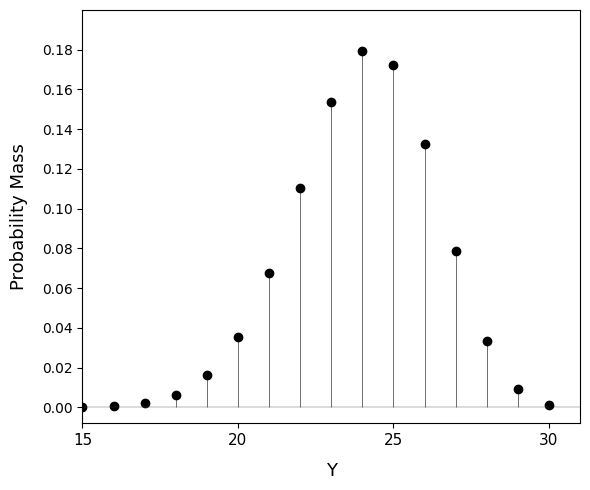

In [ ]:
# @title Example 4: Plot Poisson pmf

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials = 30     # Number of trials
prob = 0.8          # Probability of success
x_lim = (15, 31)
x_ticks = np.arange(15, 31, 5)
x_tick_labels = ['15', '20', '25', '30']
y_lim = (-0.008, 0.20)
y_ticks = np.arange(0.00, 0.20, 0.02)
y_tick_labels = [f'{v:.2f}' for v in np.arange(0.00, 0.20, 0.02)]

# ──────────────────────────────────────────────────────────────────────────────

# Binomial outcomes and their probabilities
x_values = np.arange(0, num_trials + 1)
probabilities = binom.pmf(x_values, num_trials, prob)

# Create the figure -------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Stem plot (vertical lines from x-axis to each point)
markerline, stemlines, baseline = ax.stem(
    x_values, probabilities,
    linefmt='k-',       # black vertical lines
    markerfmt='ko',     # black circular markers
    basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Add baseline
ax.axhline(y=0, color='k', linewidth=0.2)

# Set X-axis ---------------------------------------
ax.set_xlim(x_lim)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, fontsize = 11)

# Set Y-axis --------------------------------------
ax.set_ylim(y_lim)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=10)

# Set labels --------------------------------------
ax.set_xlabel('Y', fontsize=13, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=13, labelpad=10)

# Show plot ---------------------------------------
fig.tight_layout()
plt.show()



If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image07A.png)

## **Exercise 2: Plot Biominial pmf**

In the cell below, write the Python code to plot the probability mass function (pmf) for a $\operatorname{Binomial}(50, 0.8)$ distribution.

**Code Hints:**

1. Copy-and-paste Example 2 into the cell below
2. Change the variables in the Input Section to read as shown in the following code chunk:
```Python
# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials = 50     # Number of trials
prob = 0.8          # Probability of success
x_lim = (29, 51)
x_ticks = np.arange(30, 49, 5)
x_tick_labels = ['30', '35', '40', '45']
y_lim = (-0.008, 0.15)
y_ticks = np.arange(0.00, 0.15, 0.02)
y_tick_labels = [f'{v:.2f}' for v in np.arange(0.00, 0.15, 0.02)]
# ──────────────────────────────────────────────────────────────────────────────

```

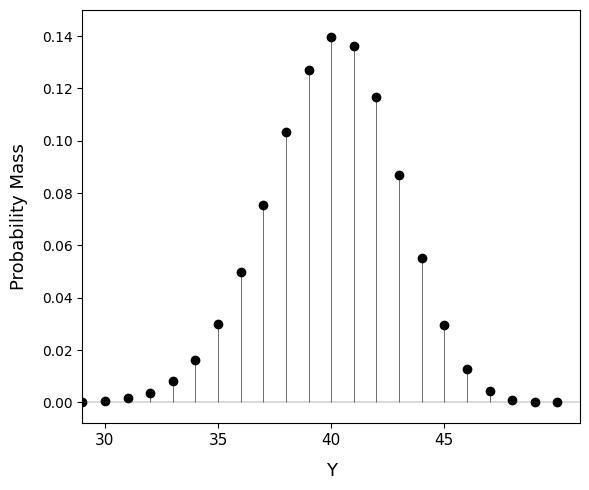

In [ ]:
# @title Exercise 2: Plot Biominial pmf

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import os

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
num_trials = 50     # Number of trials
prob = 0.8          # Probability of success
x_lim = (29, 51)
x_ticks = np.arange(30, 49, 5)
x_tick_labels = ['30', '35', '40', '45']
y_lim = (-0.008, 0.15)
y_ticks = np.arange(0.00, 0.15, 0.02)
y_tick_labels = [f'{v:.2f}' for v in np.arange(0.00, 0.15, 0.02)]
# ──────────────────────────────────────────────────────────────────────────────

# Binomial outcomes and their probabilities
x_values = np.arange(0, num_trials + 1)
probabilities = binom.pmf(x_values, num_trials, prob)

# Create the figure
fig, ax = plt.subplots(figsize=(6, 5))

# Stem plot (vertical lines from x-axis to each point)
markerline, stemlines, baseline = ax.stem(
    x_values, probabilities,
    linefmt='k-',       # black vertical lines
    markerfmt='ko',     # black circular markers
    basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Add baseline
ax.axhline(y=0, color='k', linewidth=0.2)

# Setup X-axis
ax.set_xlim(x_lim)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, fontsize=11)

# Setup Y-axis
ax.set_ylim(y_lim)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=10)

# Setup Labels
ax.set_xlabel('Y', fontsize=13, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=13, labelpad=10)

# Show the plot
fig.tight_layout()
plt.show()


If your code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image08A.png)

The output illustrates the probabilities for different possible values of $Y$. As before, the height of each bar is the probability of the corresponding value on the `X-axis`. For example, the probability of $35$ survivals (out of $50$) is $0.03$, and the probability of $36$ survivals is $0.05$. Also, since the probabilities for all possible values of the random variable add to $1$, the bar heights add up to $1$. Note that even though $Y$ can take integer values from $0$ to $50$, the plot does not show numbers below $30$ and above $48$ since the probability of these values is almost zero. For example, for the given survival probability, it is extremely unlikely to have only $10$ survivals.

Now suppose that we are interested in the probability that either $34$ or $35$ or $36$ patients survive. Since the underlying event includes three possible outcomes, $34$, $35$, and $36$, we obtain the probability by adding the individual probabilities for these outcomes:

$$
\begin{array}{l} P(Y\in \{34, 35, 36 \}) = P (33 < Y \leq 36) \\ = P (Y = 34) + P (Y = 35) + P (Y = 36) \\ = 0.02 + 0.03 + 0.05 = 0.1. \\ \end{array}
$$

This is the same as adding the bar heights for $Y = 34$, $Y = 35$, and $Y = 36$. Further, suppose that we want to find the probability that the number of survivals (out of 50) is less than or equal to 36. That is, we are interested in the probability that either no one survives, or 1 patient survives, or 2 patients survive, ..., or 36 patients survive. This is shown as $P(Y \leq 36)$ and is called the **lower tail probability** of $36$. As before, we can add up the individual probabilities to obtain

$$
P (Y \leq 36) = P (Y = 0) + P (Y = 1) + \dots + P (Y = 36).
$$

This is equivalent to adding the bar heights from $Y=0$ through $Y=36$.

We can also obtain the **upper tail probability** of $36$, which is the probability that more than $36$ patients survive: $P(Y > 36)$. Since the lower tail and upper tail probabilities represent complementary events (i.e., either 36 people or fewer survival, or more than 36 people survive), we can obtain the upper tail probability by $P(Y > 36) = 1 - P(Y \leq 36) = 1 - 0.11 = 0.89$.

-----------------

>In general, we use $P(Y \leq y)$ to denote the lower tail probability for any specific value $y$. The upper tail probability can be obtained as $P(Y > y) = 1 - P(Y \leq y)$.

-----------------

In the above example, we add the individual probabilities for outcomes 34, 35, and 36 to obtain the interval probability $P(33 < Y \leq 36)$. Note that by convention, the intervals include the upper limit (here 36) but not the lower limit (here 33). We can write this probability as follows:

$$
P(33 < Y\leq 36) = P (Y \leq 36) - P (Y \leq 33).
$$

Here, we are subtracting the probability that $Y$ is less than or equal to $33$ from the probability that $Y$ is less than or equal to $36$. For this example, $P(Y \leq 36) = 0.11$ and $P(Y \leq 33) = 0.01$. Therefore,

$$
P (33 < Y\leq 36) = 0.11 - 0.01 = 0.1.
$$

-------------------

>In general, the probability of any interval from $x_{1}$ to $x_{2}$, where $x_{1}< x_{2}$, can be obtained using the corresponding lower tail probabilities for these two points as follows:
$$
P \left(x_{1} < X \leq x_{2}\right) = P\left(X \leq x_{2}\right)-P \left(X \leq x_{1}\right).   \tag{5.1}
$$

---------------------

The above examples show that the pmf of a binomial distribution provides the required information to calculate all different probabilities. For a given pmf, we can also find the mean (expected value) and variance of the random variable.

-----------

>The theoretical (population) mean of a random variable $Y$ with Binomial $(n, \theta)$ distribution is $\mu = n\theta$. The theoretical (population) variance of $Y$ is $\sigma^{2} = n\theta(1-\theta)$.

-------------


For the breast cancer example, the mean of the random variable is $50\times 0.8 = 40$. (Note that in general the mean might not be an integer.) If we recruit $50$ patients, we expect $40$ people survive over five years. Of course, the actual number of survivors can change from one group to another (e.g., if we take another group of $50$ patients). The variance of $Y$ in the above example is $50\times 0.8 \times 0.2 = 8$, which shows the extent of the variation of the random variable around its mean.

While in practice it is difficult to repeatedly recruit groups of $50$ cancer patients, we can use Python to simulate the sampling process.

## Example 3: Binomial Sampling Simulation

The code in the cell below illustrates the how to use binomial sampling in a medical context. Here is the scenario for Example 3:

Scenario: Pancreatic Cancer: 5-year survival of 14.0%.
We simulate recruiting groups of 50 patients and count how many survive.

Expected mean: $\mu = n * p = 50 * 0.14 = 7$

In [ ]:
# @title Example 3: Binomial Sampling Simulation

import numpy as np

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
n_trials = 50           # Binomial trials (group size)
prob_success = 0.14     # Probability of success
num_samples = 10        # Number of samples (simulated groups)
num_observations = 1    # One observation per sample (raw count, not mean)
# ──────────────────────────────────────────────────────────────────────────────

# Print header info
print("=" * 55)
print("  Binomial Sampling Simulation")
print("  Binomial(n=50, p=0.14), 10 samples")
print("=" * 55)
print()
print(f"Parameters:")
print(f"  Group size (trials):         {n_trials}")
print(f"  Survival rate (probability): {prob_success}")
print(f"  Number of simulated groups:  {num_samples}")
print(f"  Expected mean (mu):          {n_trials * prob_success}")
print()

# --- Generate the samples ---
# Each sample = number of survivors out n_trials (patients)
# num_observations=1 means one count per group (not an average)
samples = np.random.binomial(n=n_trials, p=prob_success,
                             size=(num_samples, num_observations)).flatten()

# --- Display results ---
print("Simulated Data Set: BinomialSample1")
print("-" * 30)
print(f"  {'Sample':>6}  {'Survivors':>10}")
print("-" * 30)
for i, count in enumerate(samples, 1):
    print(f"  {i:>6}  {count:>10}")
print("-" * 30)
print()

# --- Summary statistics ---
sample_mean = samples.mean()
print(f"Sample mean:    {sample_mean:.1f}")
print(f"Expected mean:  {n_trials * prob_success:.1f}")
print()
print("Note: As expected, the number of survivors in each group")
print("are generally close to the mean of the distribution, mu = 7.")
print()
print("(Your simulated values will differ each time you run this.)")


  Binomial Sampling Simulation
  Binomial(n=50, p=0.14), 10 samples

Parameters:
  Group size (trials):         50
  Survival rate (probability): 0.14
  Number of simulated groups:  10
  Expected mean (mu):          7.000000000000001

Simulated Data Set: BinomialSample1
------------------------------
  Sample   Survivors
------------------------------
       1          13
       2           1
       3          13
       4           9
       5           3
       6           7
       7           7
       8           4
       9           6
      10           8
------------------------------

Sample mean:    7.1
Expected mean:  7.0

Note: As expected, the number of survivors in each group
are generally close to the mean of the distribution, mu = 7.

(Your simulated values will differ each time you run this.)


If the code is correct, you should see something _similar_ to the following output:
```text
=======================================================
  Binomial Sampling Simulation
  Binomial(n=50, p=0.14), 10 samples
=======================================================

Parameters:
  Group size (trials):         50
  Survival rate (probability): 0.14
  Number of simulated groups:  10
  Expected mean (mu):          7.000000000000001

Simulated Data Set: BinomialSample1
------------------------------
  Sample   Survivors
------------------------------
       1           7
       2          10
       3           6
       4           4
       5           4
       6           6
       7           3
       8           8
       9           2
      10           8
------------------------------

Sample mean:    5.8
Expected mean:  7.0

Note: As expected, the number of survivors in each group
are generally close to the mean of the distribution, mu = 7.

(Your simulated values will differ each time you run this.)
```

## Exercise 3: Binomial Sampling Simulation

Scenario: A cancer treatment has an 80% survival rate.
We simulate recruiting groups of 50 patients and count how many survive.

Expected mean: mu = n * p = 50 * 0.8 = 40

**Code Hints:**

1. Copy-and-paste Example 3 into the cell below
2. Change the variables in the Input Section to read as shown in the following code chunk:
```Python
# ── INPUT SECTION ─────────────────────────────────────────────────────────────
n_trials = 50           # Binomial trials (group size)
prob_success = 0.8      # Probability of success
num_samples = 10        # Number of samples (simulated groups)
num_observations = 1    # One observation per sample (raw count, not mean)
# ──────────────────────────────────────────────────────────────────────────────
```

In [ ]:
# @title Exercise 3: Binomial Sampling Simulation

import numpy as np

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
n_trials = 50           # Binomial trials (group size)
prob_success = 0.8      # Probability of success
num_samples = 10        # Number of samples (simulated groups)
num_observations = 1    # One observation per sample (raw count, not mean)
# ──────────────────────────────────────────────────────────────────────────────

# Print header info
print("=" * 55)
print("  Binomial Sampling Simulation")
print("  Binomial(n=50, p=0.8), 10 samples")
print("=" * 55)
print()
print(f"Parameters:")
print(f"  Group size (trials):         {n_trials}")
print(f"  Survival rate (probability): {prob_success}")
print(f"  Number of simulated groups:  {num_samples}")
print(f"  Expected mean (mu):          {n_trials * prob_success}")
print()

# --- Generate the samples ---
# Each sample = number of survivors out n_trials (patients)
# num_observations=1 means one count per group (not an average)
samples = np.random.binomial(n=n_trials, p=prob_success,
                             size=(num_samples, num_observations)).flatten()

# --- Display results ---
print("Simulated Data Set: BinomialSample1")
print("-" * 30)
print(f"  {'Sample':>6}  {'Survivors':>10}")
print("-" * 30)
for i, count in enumerate(samples, 1):
    print(f"  {i:>6}  {count:>10}")
print("-" * 30)
print()

# --- Summary statistics ---
sample_mean = samples.mean()
print(f"Sample mean:    {sample_mean:.1f}")
print(f"Expected mean:  {n_trials * prob_success:.1f}")
print()
print("Note: As expected, the number of survivors in each group")
print("are generally close to the mean of the distribution, mu = 40.")
print()
print("(Your simulated values will differ each time you run this.)")


  Binomial Sampling Simulation
  Binomial(n=50, p=0.8), 10 samples

Parameters:
  Group size (trials):         50
  Survival rate (probability): 0.8
  Number of simulated groups:  10
  Expected mean (mu):          40.0

Simulated Data Set: BinomialSample1
------------------------------
  Sample   Survivors
------------------------------
       1          43
       2          39
       3          36
       4          39
       5          37
       6          42
       7          38
       8          38
       9          38
      10          39
------------------------------

Sample mean:    38.9
Expected mean:  40.0

Note: As expected, the number of survivors in each group
are generally close to the mean of the distribution, mu = 40.

(Your simulated values will differ each time you run this.)


If your code is correct, you should see something _similar_ to the following output:

```text

=======================================================
  Binomial Sampling Simulation
  Binomial(n=50, p=0.8), 10 samples
=======================================================

Parameters:
  Group size (trials):         50
  Survival rate (probability): 0.8
  Number of simulated groups:  10
  Expected mean (mu):          40.0

Simulated Data Set: BinomialSample1
------------------------------
  Sample   Survivors
------------------------------
       1          37
       2          38
       3          37
       4          41
       5          39
       6          36
       7          44
       8          37
       9          40
      10          40
------------------------------

Sample mean:    38.9
Expected mean:  40.0

Note: As expected, the number of survivors in each group
are generally close to the mean of the distribution, mu = 40.

(Your simulated values will differ each time you run this.)

```

An example of the resulting data set is shown in the output above. (Your simulated sample would be different.) In this simulated data set, $37$ patients survive in the first group, $38$ patients survive in the second group, and so forth. As expected, the number of survivors are generally close to the mean of the distribution, $\mu = 40$.

### **_5.4.3 Poisson Distribution_**

So far, we have discussed the Bernoulli distribution for binary variables, and the binomial distribution for the number of times the outcome of interest (one of the two possible categories of the binary variable) occur within a set of n Bernoulli trials. While a random variable with a Binomial $ (n,\theta) $ distribution is a count variable (e.g., number of people survived), its range is restricted to include integers from 0 through n only. For example, the number of survivals in a group of $n = 50$ cancer patients cannot exceed $50$. Now, suppose that we are investigating the number of physician visits for each person in one year. Although very large numbers such as 100 are quite unlikely, there is no theoretical and prespecified upper limit to this random variable. Theoretically, its range is the set of all nonnegative integers. As another example, consider the number of trees per square mile in a certain region. Again, although spatial limits make very large numbers unlikely, there is no theoretical and prespecified limit for the possible values of the random variable.


-----------------------

>Random variables representing counts within temporal and/or spatial limits but without prespecified upper limits are often assumed to have **Poisson** distributions. The range of these variables is the set of all nonnegative integers (i.e., the lower limit is zero, but there is no upper limit). A Poisson distribution is specified by a parameter $\lambda$, which is interpreted as the rate of occurrence within a time period or space limit. We show this as $X\sim\text{Poisson}(\lambda)$, where $\lambda$ is a positive real number ($\lambda>0$). The mean and variance of a random variable with Poisson($\lambda$) distribution are the same and equal to $\lambda$. That is, $\mu =\lambda$ and $\sigma^{2}=\lambda$.

----------------------


## Example 4: Plot Poisson pmf

The code in the cell below shows the Python code to plot the probability mass function (pmf) for a $\operatorname{Poisson}(6.5)$ distribution.

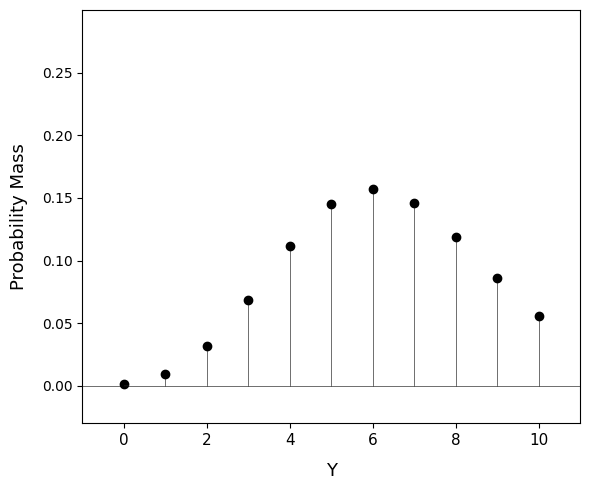

In [ ]:
# @title Example 4: Plot Poisson pmf

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import poisson


# ── INPUT SECTION ─────────────────────────────────────────────────────────────
lambda_param = 6.5
# ──────────────────────────────────────────────────────────────────────────────

# Poisson outcomes and their probabilities
x_values = np.arange(0, 11)
probabilities = poisson.pmf(x_values, lambda_param)

# Create the figure ----------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Setup stem plot ------------------------------------
markerline, stemlines, baseline = ax.stem(
  x_values, probabilities,
  linefmt='k-',       # black vertical lines
  markerfmt='ko',     # black circular markers
  basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Horizontal line at y=0 -----------------------------
ax.axhline(y=0, color='k', linewidth=0.4)

# Set X-axis -----------------------------------------
ax.set_xlim(-1, 11)
ax.set_xticks(np.arange(0, 11, 2))
ax.set_xticklabels(['0', '2', '4', '6', '8', '10'], fontsize=11)

# Set Y-axis -----------------------------------------
ax.set_ylim(-0.03, 0.30)
ax.set_yticks(np.arange(0.00, 0.30, 0.05))
ax.set_yticklabels([f'{v:.2f}' for v in np.arange(0.00, 0.30, 0.05)], fontsize=10)

# Set labels -----------------------------------------
ax.set_xlabel('Y', fontsize=13, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=13, labelpad=10)

# Show the plot
fig.tight_layout()
plt.show()

If your code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image09A.png)

## Exercise 4: Plot Poisson pmf

In the cell below, write the Python code to plot the probability mass function (pmf) for a $\operatorname{Poisson}(2.5)$ distribution.

**Code Hints:**

1. Copy-and-paste Example 4 into the cell below.
2. Change `lambda_param` to 2.5

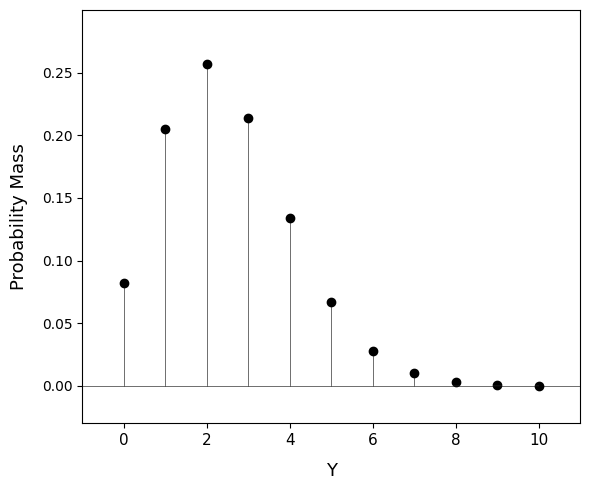

In [ ]:

# @title Exercise 4: Plot Poisson pmf

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import poisson

# ── INPUT SECTION ─────────────────────────────────────────────────────────────
lambda_param = 2.5
# ──────────────────────────────────────────────────────────────────────────────


# Poisson outcomes and their probabilities
x_values = np.arange(0, 11)
probabilities = poisson.pmf(x_values, lambda_param)

# Create the figure ----------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Setup stem plot ------------------------------------
markerline, stemlines, baseline = ax.stem(
  x_values, probabilities,
  linefmt='k-',       # black vertical lines
  markerfmt='ko',     # black circular markers
  basefmt='w'
)

# Style the stemlines line
plt.setp(stemlines, linewidth=0.4)
plt.setp(baseline, linewidth=0.1)

# Horizontal line at y=0 -----------------------------
ax.axhline(y=0, color='k', linewidth=0.4)

# Set X-axis -----------------------------------------
ax.set_xlim(-1, 11)
ax.set_xticks(np.arange(0, 11, 2))
ax.set_xticklabels(['0', '2', '4', '6', '8', '10'], fontsize=11)

# Set Y-axis -----------------------------------------
ax.set_ylim(-0.03, 0.30)
ax.set_yticks(np.arange(0.00, 0.30, 0.05))
ax.set_yticklabels([f'{v:.2f}' for v in np.arange(0.00, 0.30, 0.05)], fontsize=10)

# Set labels -----------------------------------------
ax.set_xlabel('Y', fontsize=13, labelpad=10)
ax.set_ylabel('Probability Mass', fontsize=13, labelpad=10)

# Show the plot
fig.tight_layout()
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_05/chapter_05A_image10A.png)

As an example, assume that the rate of physician visits per year is $2.5$: $X\sim$ Poisson(2.5). The population mean and variance of this variable is therefore $2.5$.

The pmf plot above shows the probability of each possible value, which is any integer from 0 to infinity. In this case, the probability of values above 8 becomes almost 0. According to this distribution, the probability of one visit per year is $P(X = 1) = 0.21$. Also, the plot of pmf shows that it is very unlikely that a person visits her physician 10 times per year.

# **Electronic Submission**

When you run the code in the cell below, it will grade your Colab notebook and tell you your pending grade as it currently stands. You will be given the choice to either submit your notebook for final grading or the option to continue your work on one (or more) Exercises.

Grant Access to your Colab Secrets if you are asked to do so.

In [ ]:
# @title Electronic Submission

import urllib.request
import ssl
import time

url = "https://biologicslab.co/STA1403/backend_code/validate.py?v=" + str(time.time())

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

req = urllib.request.Request(
    url,
    headers={
        "Cache-Control": "no-cache, no-store, must-revalidate",
        "Pragma": "no-cache",
        "Expires": "0"
    }
)

with urllib.request.urlopen(req, context=ctx) as r:
    exec(r.read().decode("utf-8"))

main()